<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/R/R_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data = read.csv("ads.csv")

library(caTools)
split = sample.split(data$Purchased, SplitRatio = 0.75)
training_set = subset(data, split == TRUE)
test_set = subset(data, split == FALSE)

data$Purchased = factor(data$Purchased, levels = c(0, 1))

training_set[, 1:2] = scale(training_set[, 1:2])
test_set[, 1:2] = scale(test_set[, 1:2])

# logistic regression
classifier = glm(formula = Purchased ~ Age + EstimatedSalary,
                 data = training_set, family = "binomial")

pred = predict(classifier, newdata = test_set, type = "response")
pred = ifelse(pred > 0.5, 1, 0)

cm = table(test_set$Purchased, pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

   pred
     0  1
  0 58  6
  1 10 26

[1] 0.84

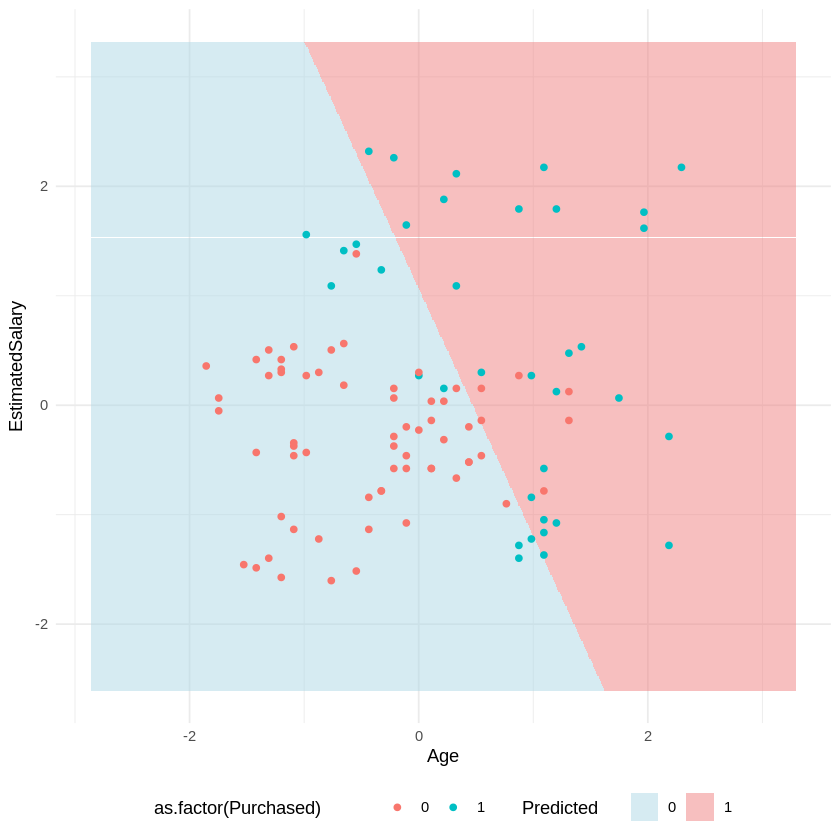

In [ ]:
library(ggplot2)

X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

prob_set = predict(classifier, type = 'response', newdata = grid_set)
y_grid = ifelse(prob_set > 0.5, 1, 0)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")

In [ ]:
# knn

library(class)

y_pred = knn(train = training_set, test = test_set, cl = training_set$Purchased, k = 5)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

   y_pred
     0  1
  0 64  0
  1  0 36

[1] 1

In [ ]:
# svm

# install.packages("e1071")
library(e1071)

classifier = svm(formula = Purchased ~ .,
  data = training_set,
  type = "C-classification",
  kernel = "linear")

y_pred = predict(classifier, newdata = test_set)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy


Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




   y_pred
     0  1
  0 59  5
  1 12 24

[1] 0.83

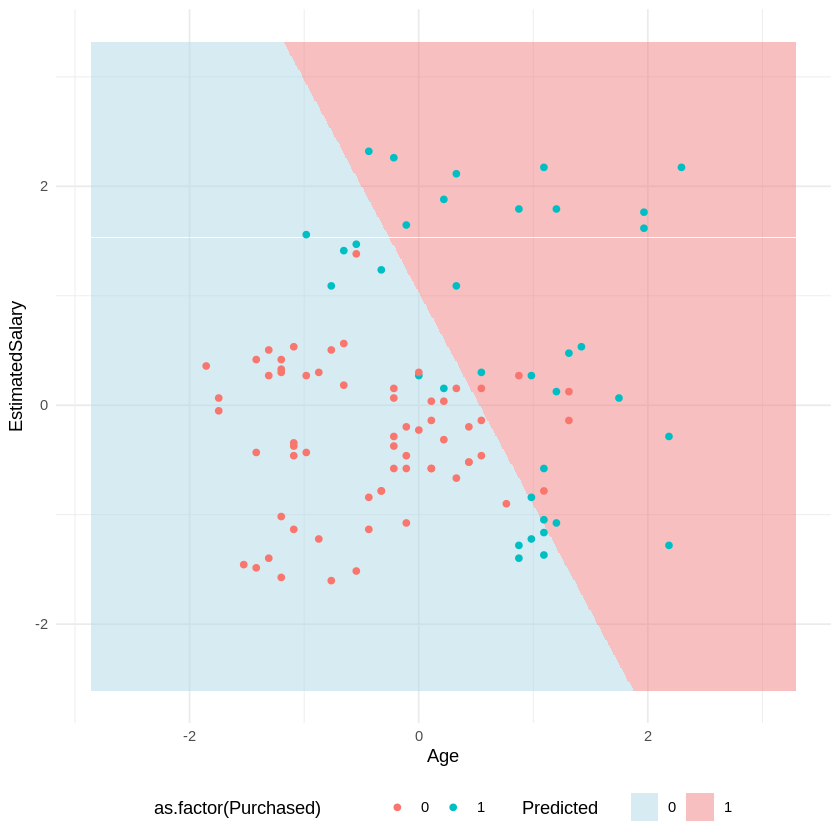

In [ ]:
X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

y_grid = predict(classifier, newdata = grid_set)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")

In [ ]:
# kernel svm

classifier = svm(formula = Purchased ~ .,
  data = training_set,
  type = "C-classification",
  kernel = "radial")

y_pred = predict(classifier, newdata = test_set)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

   y_pred
     0  1
  0 58  6
  1  3 33

[1] 0.91

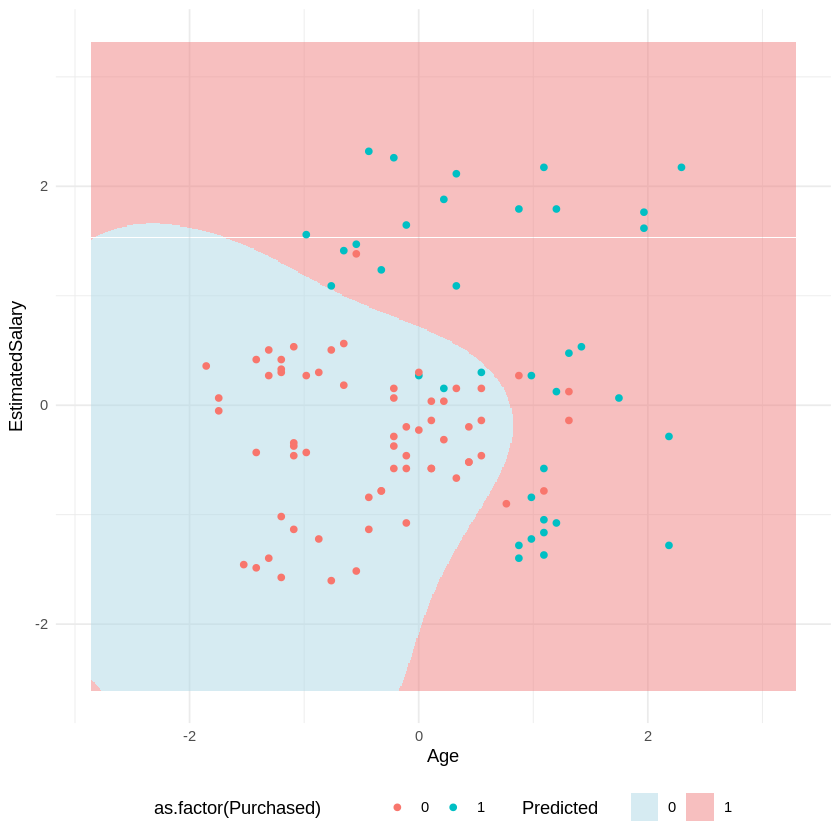

In [ ]:
X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

y_grid = predict(classifier, newdata = grid_set)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")

In [ ]:
# naive bayes

classifier = naiveBayes(x = training_set[, -3], y = training_set$Purchased)

y_pred = predict(classifier, newdata = test_set)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

   y_pred
     0  1
  0 60  4
  1  8 28

[1] 0.88

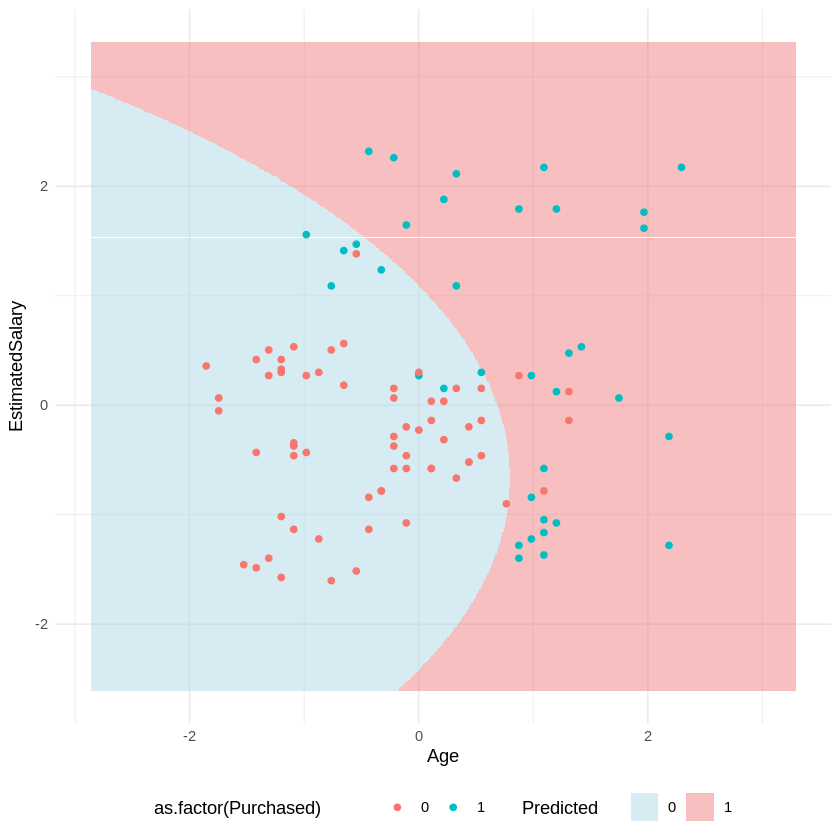

In [ ]:
X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

y_grid = predict(classifier, newdata = grid_set)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")

In [ ]:
# decision tree

# install.packages("rpart")
library(rpart)

classifier = rpart(formula = Purchased ~ .,
  data = training_set)

y_pred_raw = predict(classifier, newdata = test_set)

y_pred = ifelse(y_pred_raw > 0.5, 1, 0)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

   y_pred
     0  1
  0 52 12
  1  2 34

[1] 0.86

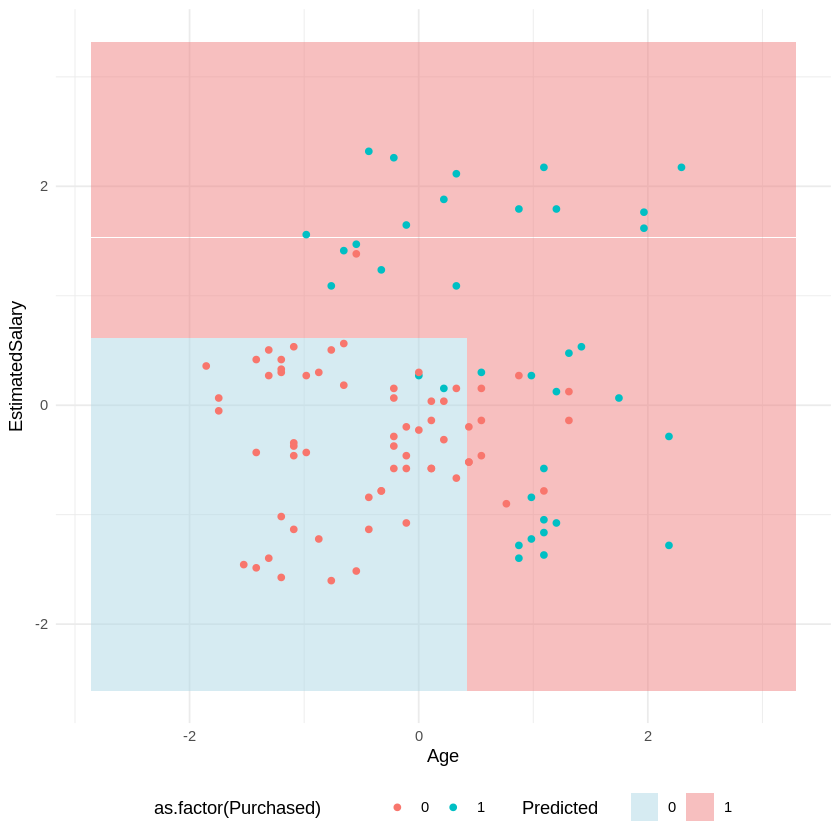

In [ ]:
X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

y_grid_raw = predict(classifier, newdata = grid_set)

y_grid = ifelse(y_grid_raw > 0.5, 1, 0)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")

In [ ]:
# random forest

# install.packages("randomForest")
library(randomForest)

classifier = randomForest(x = training_set[, -3], y = training_set$Purchased,
  ntree = 100)

y_pred_raw = predict(classifier, newdata = test_set)

y_pred = ifelse(y_pred_raw > 0.5, 1, 0)

cm = table(test_set$Purchased, y_pred)
accuracy = (cm[1,1] + cm[2,2]) / (sum(cm))
cm
accuracy

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


Warning message in randomForest.default(x = training_set[, -3], y = training_set$Purchased, :
“The response has five or fewer unique values.  Are you sure you want to do regression?”


   y_pred
     0  1
  0 59  5
  1  5 31

[1] 0.9

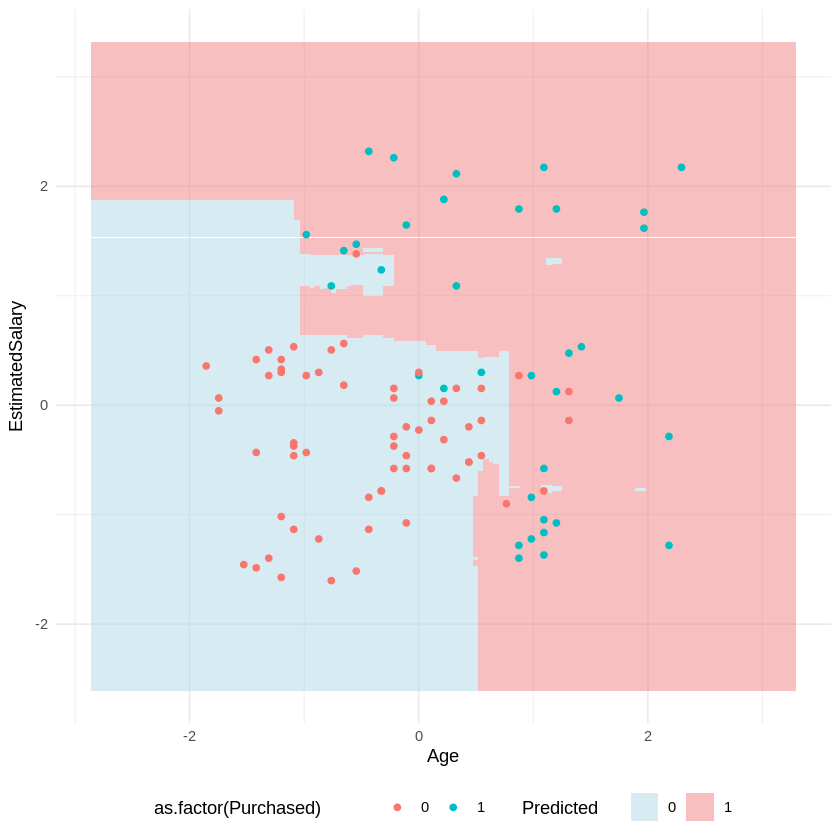

In [ ]:
X1 = seq(min(test_set[, 1]) - 1, max(test_set[, 1]) + 1, by = 0.01)
X2 = seq(min(test_set[, 2]) - 1, max(test_set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('Age', 'EstimatedSalary')

y_grid_raw = predict(classifier, newdata = grid_set)

y_grid = ifelse(y_grid_raw > 0.5, 1, 0)

plot_set = data.frame(grid_set, Predicted = factor(y_grid))

ggplot() +
  geom_tile(data = plot_set, aes(x = Age, y = EstimatedSalary, fill = Predicted), alpha = 0.5) +
  geom_point(data = test_set, aes(x = Age, y = EstimatedSalary, color = as.factor(Purchased))) +
  scale_fill_manual(values = c('0' = 'lightblue', '1' = 'lightcoral')) +
  labs(fill = 'Predicted') +
  theme_minimal() +
  theme(legend.position = "bottom")